## Naive Bayes
Naive Bayes is a statistical classification technique based on Bayes Theorem. It is one of the simplest supervised learning algorithms. Naive Bayes classifier is the fast, accurate and reliable algorithm. Naive Bayes classifiers have high accuracy and speed on large datasets.

Naive Bayes classifier assumes that the effect of a particular feature in a class is independent of other features. For example, a loan applicant is desirable or not depending on his/her income, previous loan and transaction history, age, and location. Even if these features are interdependent, these features are still considered independently. This assumption simplifies computation, and that's why it is considered as naive. This assumption is called class conditional independence.

Naive Bayes classifers calculate the probability of something belonging to a class using Bayes' theorem:
```
P(H|E) = (P(E|H) * P(H)) / P(E) 
```
where
* `P(H|E)` is the probability of hypothesis `H` given the event `E`, a posterior probability.
* `P(E|H)` is the probability of event `E` given that the hypothesis `H` is true.
* `P(H)` is the probability of hypothesis `H` being true (regardless of any related event), or prior probability of `H`.
* `P(E)` is the probability of the event occurring (regardless of the hypothesis).

You can also reference the Wikipedia article for an explanation of Bayes' theorem:
* https://en.wikipedia.org/wiki/Bayes%27_theorem

And here is another tutorial explaining Naive Bayes classifiers:
* https://www.datacamp.com/community/tutorials/naive-bayes-scikit-learn

## Example of Bayes' theorem
Suppose that a test for using a particular drug is 99% sensitive and 99% specific. That is, the test will produce 99% true positive results for drug users and 99% true negative results for non-drug users. Suppose that 0.5% of people are users of the drug. What is the probability that a randomly selected individual with a positive test is a drug user?

<img width="500px" src="images/Bayes_drug_example.png" />

Even if an individual tests positive, it is more likely that they do not use the drug than that they do. This is because the number of non-users is large compared to the number of users. The number of false positives outweighs the number of true positives. For example, if 1000 individuals are tested, there are expected to be 995 non-users and 5 users. From the 995 non-users, 0.01 × 995 ≃ 10 false positives are expected. From the 5 users, 0.99 × 5 ≈ 5 true positives are expected. Out of 15 positive results, only 5 are genuine.

## Implementing Bayes
For our implementation of Bayes, we will use skikit-learn's GaussianNB model:
* https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html

Let's load the libraries we will be using.

In [1]:
import pandas as pds
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

For our data, we will use the **Pima Indians Diabetes** dataset we used in the tree classifier tutorial.

The dataset includes data from 768 women. The columns are defined as follows:

* `Pregnancies`: Number of times pregnant
* `Glucose`: Plasma glucose concentration a 2 hours in an oral glucose tolerance test
* `BloodPressure`: Diastolic blood pressure (mm Hg)
* `SkinThickness`: Triceps skin fold thickness (mm)
* `Insulin`: 2-Hour serum insulin (mu U/ml)
* `BMI`: Body mass index (weight in kg/(height in m)^2)
* `DiabetesPedigreeFunction`: The output of the pedigree function that provides measure of genetic influence and gives us an idea of the hereditary risk one might have with the onset of diabetes mellitus
* `Age`: Age (years)
* `Outcome`: Class variable (0 or 1) 268 of 768 are 1 (positive), the others are 0 (negative)

In [2]:
## load Pima Indians Diabetes dataset (downloaded May 14, 2019; N=768)
df = pds.read_csv("diabetes.csv")

In the tree classifer tutorial, we already inspected the data. So, we are going to skip that step. But, we still need to drop the invalid rows.

In [3]:
## funciton to determine of a row has an invalid value
def valid_value(row):
    if 0 == row['Glucose'] or \
       0 == row['BloodPressure'] or \
       0 == row['SkinThickness'] or \
       0 == row['Insulin'] or \
       0 == row['BMI'] or \
       0 == row['Age']:
        return False
    else:
        return True

## create dataframe with only valid rows
df_pima = df[df.apply(lambda row: valid_value(row), axis=1)]
df_pima.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
6,3,78,50,32,88,31.0,0.248,26,1
8,2,197,70,45,543,30.5,0.158,53,1
13,1,189,60,23,846,30.1,0.398,59,1


Compare the size of the new and original dataframes, and verify the new dataframe no longer has `0`s in appropriate columns.

In [4]:
print(f"length of original dataframe:{len(df)}")
print(f"length of filtered dataframe:{len(df_pima)}")

length of original dataframe:768
length of filtered dataframe:392


In [5]:
df_pima.describe().loc['min']

Pregnancies                  0.000
Glucose                     56.000
BloodPressure               24.000
SkinThickness                7.000
Insulin                     14.000
BMI                         18.200
DiabetesPedigreeFunction     0.085
Age                         21.000
Outcome                      0.000
Name: min, dtype: float64

Now we split the data into our training and test sets.

Recall that by convention, scikit-learn often refers to the feature dataset as `X` and the target dataset as `y`.


In [6]:
## split dataset in features and target variable
feature_cols = \
    ['Pregnancies', 'Insulin', 'BMI', 'Age','Glucose',
     'BloodPressure','DiabetesPedigreeFunction', 'SkinThickness']

X = df_pima[feature_cols]
y = df_pima['Outcome']

In [7]:
## split dataset into training set and test set
X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.3, random_state=1) # 70% training and 30% test


Finally, the test and training data is fit to our model and we predict outcomes.

In [8]:
## create a Gaussian Naive Bayes classifier and predict
model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

## Evaluating Naive Bayes
To evaluate our Naive Bayes model, we will exame the confusion matrix, accuracy score, recall score, precision score, f1 score, and classifion report. 

**Accuracy:**
* (TP + TN) / (TP + TN + FP + FN)
* Accuracy is the ratio of correct predictions to total predictions made. However, there are problems with accuracy. It assumes equal costs for both kinds of errors. A 99% accuracy can be excellent, good, mediocre, poor or terrible depending upon the problem.


**Recall:**
* TP / (TP + FN)
* Recall is the ability of a classifier to find all positive instances. High recall indicates a small number of false negatives.


**Precision:**
* TP / (TP + FP)
* Precision is the ability of a classifier not to label an instance positive that is actually negative. High precision indicates a small number of false positives.

**F1 score (F measure):**
* (2 * Recall * Precision) / (Recall + Precision)
* Since we have two measures (Precision and Recall) it helps to have a measurement that represents both of them. We calculate an F1 score that uses Harmonic Mean in place of Arithmetic Mean as it punishes the extreme values more. 

In [9]:
def show_confusion_matrix(y_test, y_pred, palette="Set3"):
    ## see: https://www.geeksforgeeks.org/confusion-matrix-machine-learning/
    ##      https://jakevdp.github.io/PythonDataScienceHandbook/05.08-random-forests.html
    ##      https://classeval.wordpress.com/introduction/basic-evaluation-measures/
    matrix = confusion_matrix(y_test, y_pred)

    colors = sns.color_palette(palette) # set the colors to use for heatmap
    # print(colors.as_hex()) # uncomment this to see color palette

    ax = sns.heatmap(matrix, square=True, annot=True, fmt='d', 
                     cbar=False, cmap=colors, vmin=-1, annot_kws={"size":13}, linewidths=1.0)

    # set labels on figure
    ax.set_xticklabels(labels=["neg","pos"], fontsize=13)
    ax.set_yticklabels(labels=["neg","pos"], fontsize= 13)
    plt.xlabel("\nactual value", fontsize=15)
    plt.ylabel("predicted value\n", fontsize=15)
    plt.show()

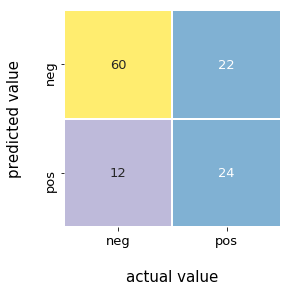

In [10]:
## show confustion matrix
show_confusion_matrix(y_test, y_pred)

In [11]:
accuracy_score(y_test, y_pred)

0.711864406779661

In [12]:
recall_score(y_test, y_pred)

0.6666666666666666

In [13]:
precision_score(y_test, y_pred)

0.5217391304347826

In [14]:
f1_score(y_test, y_pred)

0.5853658536585366

How do your results compare to the decision tree and random forest models?

## Wrapping up
In this module, we covered the basics of implementing and evaluating a Naive Bayes classifier in scikit learns.